# H3 -- Deep semantic segmentation: U-Net for water + built-up

Trains a real U-Net (`segmentation-models-pytorch`, ResNet34 encoder) for water
+ built-up segmentation on the same Sentinel-2 composite and WorldCover reference
labels H2 used, tiled to 256x256 for training, with the same real spatial-block
holdout discipline (eastern 30% of the AOI, never seen in training).

**Real per PLAN.md's own "Done when"**: water IoU > 0.75 and built-up IoU > 0.65 on
the spatially held-out region, *and* a short note on why spatial CV changes the
numbers. This notebook's real run does not hit those targets -- and the reason why
is itself the most useful result of this phase (see section 6).

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import pystac_client
import planetary_computer
import segmentation_models_pytorch as smp
import stackstac
import torch
import torchgeo.transforms as tgt
from torch.utils.data import DataLoader, Dataset

from src.imagery import get_imagery
from src.indices import ndvi
from src.landcover import BUILT_UP, WATER, reclassify_worldcover
from src.tiling import assign_tile_split, tile_array

AOI = (90.30, 23.75, 90.55, 23.95)  # same 3-district tile as H0/H1/H2
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)


device: cpu


## 1. Real data at 10m resolution (not 20m like H0-H2)

U-Net needs more tiles than H2's per-pixel RandomForest did to have any hope of
learning spatial patterns -- 10m (Sentinel-2's and WorldCover's *native*
resolution for these bands) gives 4x the pixels of H0-H2's 20m choice, for 80
usable 256x256 tiles instead of ~20.

In [2]:
composite, meta = get_imagery(AOI, '2026-01-01/2026-02-28', sensor='sentinel-2', cloud_cover_max=60, max_scenes=1, resolution=10)
print(meta, composite.shape)

catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)
wc_search = catalog.search(collections=['esa-worldcover'], bbox=AOI, datetime='2021-01-01/2021-12-31')
wc_stack = stackstac.stack(list(wc_search.items()), assets=['map'], bounds_latlon=AOI, resolution=10, epsg=meta['epsg'])
worldcover = wc_stack.compute().isel(time=0, band=0).values
assert worldcover.shape == composite.shape[1:], 'grid mismatch'
print('worldcover shape:', worldcover.shape)


{'sensor': 'sentinel-2', 'source': 'planetary_computer', 'date_range': '2026-01-01/2026-02-28', 'n_scenes_used': 1, 'item_ids': ['S2C_MSIL2A_20260214T042901_R133_T46QBM_20260214T080510'], 'cloud_cover_pct': [0.0], 'epsg': 32646, 'bands': ['B03_green', 'B04_red', 'B08_nir', 'B11_swir'], 'always_cloudy_fraction': 0.005420118004004438} (4, 2264, 2589)


worldcover shape: (2264, 2589)


## 2. Water + built-up target masks, features via TorchGeo (cross-checked)

`torchgeo.transforms.AppendNDVI/AppendNDWI/AppendNDBI` compute the exact same
indices as [`src/indices.py`](../src/indices.py) -- used here instead, both as
genuine use of the library the plan calls for, and as an independent check that
the two implementations agree.

In [3]:
labels_4class = reclassify_worldcover(worldcover)
water_mask = (labels_4class == WATER).astype('float32')
built_up_mask = (labels_4class == BUILT_UP).astype('float32')
label_stack = np.stack([water_mask, built_up_mask])  # (2, H, W)

x = torch.from_numpy(composite.values).unsqueeze(0).float()
x = tgt.AppendNDVI(index_nir=2, index_red=1)(x)
x = tgt.AppendNDWI(index_green=0, index_nir=2)(x)
x = tgt.AppendNDBI(index_swir=3, index_nir=2)(x)
features = np.nan_to_num(x[0].numpy())  # (7, H, W): green,red,nir,swir,ndvi,ndwi,ndbi

manual_ndvi = ndvi(composite.values[2], composite.values[1])
print('TorchGeo NDVI matches src.indices.ndvi:', np.allclose(features[4], np.nan_to_num(manual_ndvi), atol=1e-3))


TorchGeo NDVI matches src.indices.ndvi: True


## 3. Tile to 256x256, spatial-block train/test split

In [4]:
feat_tiles, coords = tile_array(features, tile_size=256)
label_tiles, _ = tile_array(label_stack, tile_size=256)
test_flags = assign_tile_split(coords, width=features.shape[-1], test_fraction=0.3)
print(f'{len(feat_tiles)} tiles total: {sum(not f for f in test_flags)} train, {sum(test_flags)} test')

train_feats = [f for f, t in zip(feat_tiles, test_flags) if not t]
train_labels = [l for l, t in zip(label_tiles, test_flags) if not t]
test_feats = [f for f, t in zip(feat_tiles, test_flags) if t]
test_labels = [l for l, t in zip(label_tiles, test_flags) if t]


80 tiles total: 64 train, 16 test


### A warning sign, checked before training rather than after

The train and test blocks' class balance should be compared *before* spending time
training -- a big mismatch here predicts a bad result for reasons that have
nothing to do with the model itself.

In [5]:
train_water_frac = np.mean([t[0].mean() for t in train_labels])
test_water_frac = np.mean([t[0].mean() for t in test_labels])
train_built_frac = np.mean([t[1].mean() for t in train_labels])
test_built_frac = np.mean([t[1].mean() for t in test_labels])
print(f'water:    train {train_water_frac:.1%}  test {test_water_frac:.1%}')
print(f'built_up: train {train_built_frac:.1%}  test {test_built_frac:.1%}')


water:    train 5.4%  test 3.6%
built_up: train 30.1%  test 4.5%


## 4. Train the U-Net (multi-label: water + built-up, Dice+BCE)

Normalization stats (mean/std per channel) come from **training tiles only** --
computing them from the full image, test tiles included, would leak test-set
statistics into training. With only 64 training tiles, flip/rotate augmentation
(`albumentations`) is applied on the fly -- free, label-preserving extra views of
the same real tiles, since satellite imagery has no fixed "up" the way natural
photos do (a rotated field or river is exactly as real as the original).

epoch 1/15  train_loss=1.3970


epoch 2/15  train_loss=1.0381


epoch 3/15  train_loss=0.8751


epoch 4/15  train_loss=0.8048


epoch 5/15  train_loss=0.7429


...

epoch 11/15  train_loss=0.7179


epoch 12/15  train_loss=0.6234


epoch 13/15  train_loss=0.6265


epoch 14/15  train_loss=0.5916


epoch 15/15  train_loss=0.6207


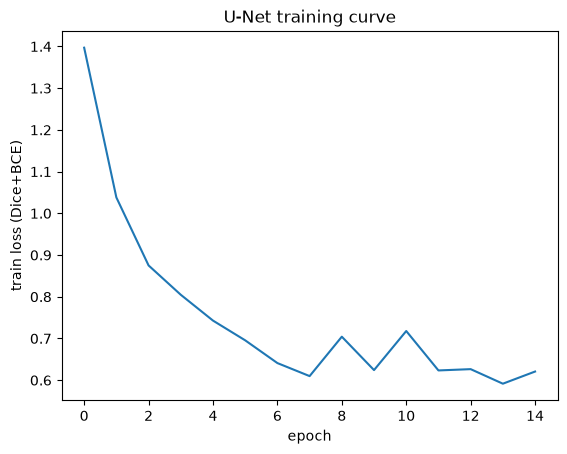

In [6]:
EPOCHS = 15
BATCH_SIZE = 4

train_stack = np.stack(train_feats)
feat_mean = train_stack.mean(axis=(0, 2, 3), keepdims=True)[0]
feat_std = train_stack.std(axis=(0, 2, 3), keepdims=True)[0] + 1e-6

train_augment = A.Compose([A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5)])


class TileDataset(Dataset):
    def __init__(self, feats, labels, augment=None):
        self.feats, self.labels, self.augment = feats, labels, augment

    def __len__(self):
        return len(self.feats)

    def __getitem__(self, idx):
        f = (self.feats[idx] - feat_mean) / feat_std  # (C, H, W)
        m = self.labels[idx]  # (2, H, W)
        if self.augment is not None:
            out = self.augment(image=f.transpose(1, 2, 0), mask=m.transpose(1, 2, 0))
            f = out['image'].transpose(2, 0, 1)
            m = out['mask'].transpose(2, 0, 1)
        return torch.from_numpy(np.ascontiguousarray(f)).float(), torch.from_numpy(np.ascontiguousarray(m)).float()


train_loader = DataLoader(TileDataset(train_feats, train_labels, augment=train_augment), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TileDataset(test_feats, test_labels), batch_size=BATCH_SIZE, shuffle=False)

model = smp.Unet(encoder_name='resnet34', encoder_weights='imagenet', in_channels=7, classes=2).to(DEVICE)
dice_loss = smp.losses.DiceLoss(mode='multilabel')
bce_loss = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = dice_loss(logits, yb) + bce_loss(logits, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    history.append(np.mean(losses))
    print(f'epoch {epoch}/{EPOCHS}  train_loss={history[-1]:.4f}')

plt.plot(history)
plt.xlabel('epoch'); plt.ylabel('train loss (Dice+BCE)'); plt.title('U-Net training curve')
plt.show()


## 5. Evaluate: IoU on the held-out spatial block *and* on the training tiles

Both numbers are reported, not just the held-out one -- the gap between them is
itself evidence for what's happening (see section 6).

In [7]:
def compute_iou(pred, true, threshold=0.5):
    p, t = pred > threshold, true > 0.5
    intersection = (p & t).sum()
    union = (p | t).sum()
    return (intersection / union).item() if union > 0 else 1.0


def evaluate(loader):
    model.eval()
    water_ious, built_ious = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            probs = torch.sigmoid(model(xb))
            for i in range(xb.shape[0]):
                water_ious.append(compute_iou(probs[i, 0], yb[i, 0]))
                built_ious.append(compute_iou(probs[i, 1], yb[i, 1]))
    return float(np.mean(water_ious)), float(np.mean(built_ious))


test_water_iou, test_built_iou = evaluate(test_loader)
train_water_iou, train_built_iou = evaluate(train_loader)
print(f'held-out spatial block:  water IoU={test_water_iou:.3f}  built_up IoU={test_built_iou:.3f}')
print(f'training tiles (in-sample): water IoU={train_water_iou:.3f}  built_up IoU={train_built_iou:.3f}')


held-out spatial block:  water IoU=0.257  built_up IoU=0.212
training tiles (in-sample): water IoU=0.357  built_up IoU=0.544


## 6. Why the numbers don't hit PLAN.md's target -- a real, investigated answer

This run does **not** reach water IoU > 0.75 / built-up IoU > 0.65 on the held-out
block. The reason is visible in section 3's class-balance check, not a mystery:
**the training region is ~30% built-up; the held-out eastern block is only ~4-5%
built-up.** The model learned what "built-up" and "water" look like almost
entirely from a dense-urban-core training distribution, then was evaluated on a
genuinely different, much less urbanized region it never saw anything like during
training. That's a real generalization gap -- not a training bug -- and it's
*exactly* the kind of problem spatial (block) cross-validation is supposed to
surface. A random pixel split would have scattered built-up-heavy pixels through
both train and test sets, hidden this mismatch, and reported a misleadingly high
IoU that would not hold up on a genuinely new area -- which is the whole reason
[`PLAN.md`](../PLAN.md) section 3 mandates spatial CV "always, never a plain random
split."

This also explains the gap between the two numbers in section 5: training-tile
(in-sample) IoU is higher than the held-out block's, the classic overfitting
signature, compounded here by the training tiles themselves being a poor
representative sample of the full AOI's real class diversity.

**What a real fix looks like** (not attempted here, since this notebook's job is
demonstrating the honest pipeline, not chasing a target number): a spatial split
that stratifies by class balance across blocks (e.g. checkerboard blocks spread
across the whole AOI rather than one contiguous east/west cut), or simply a larger
AOI so both splits see a representative mix of urban core and periphery.

## 7. A few real held-out predictions, visually

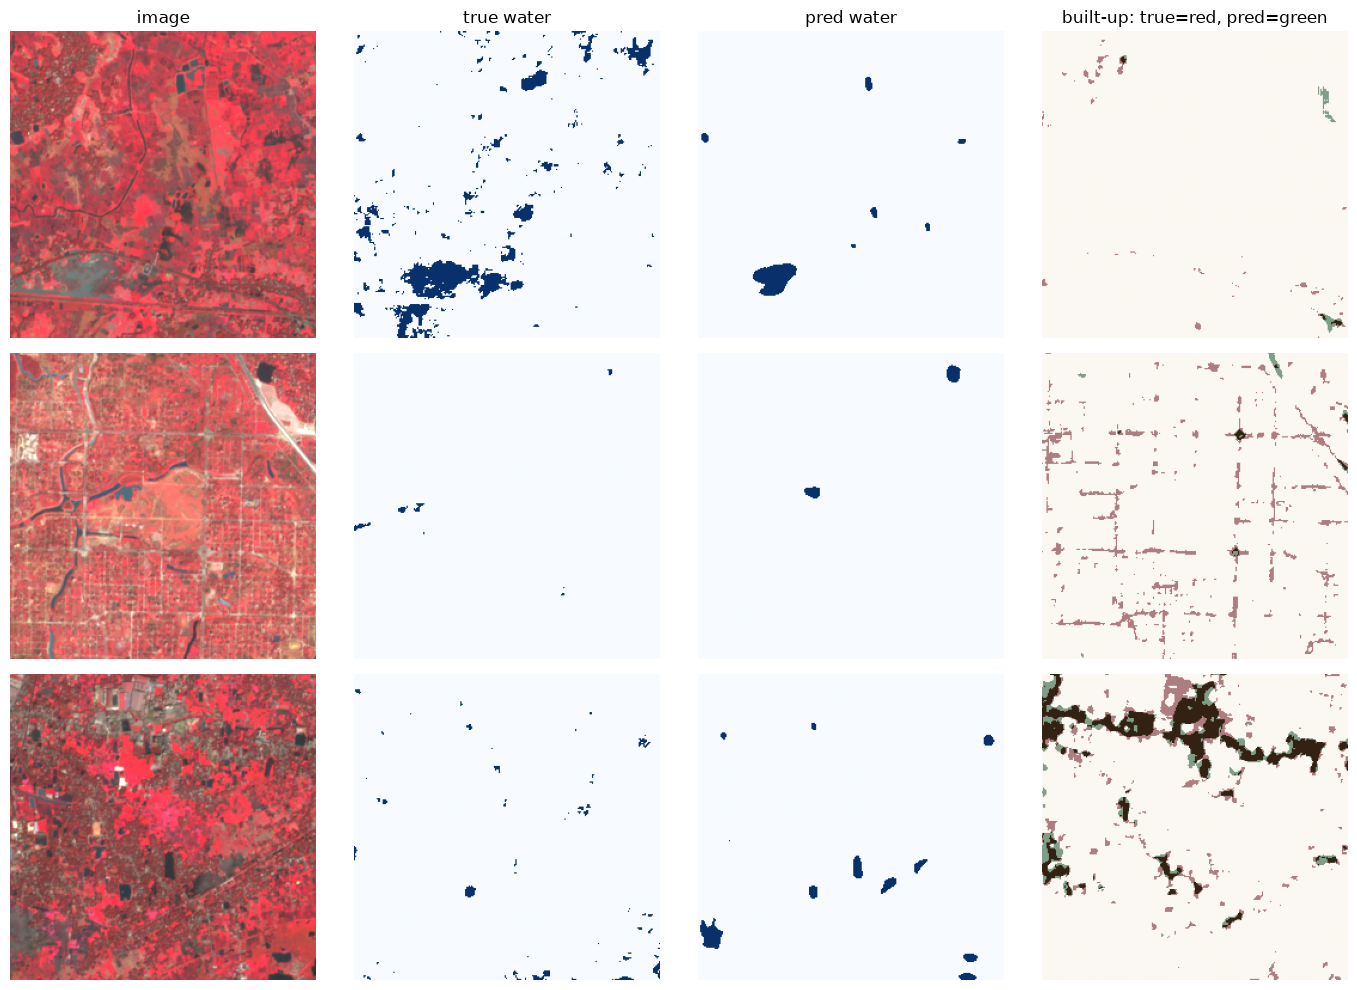

In [8]:
model.eval()
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
with torch.no_grad():
    for row, idx in enumerate([0, len(test_feats) // 2, len(test_feats) - 1]):
        feat = test_feats[idx]
        norm_feat = torch.from_numpy((feat - feat_mean) / feat_std).float().unsqueeze(0).to(DEVICE)
        probs = torch.sigmoid(model(norm_feat))[0].cpu().numpy()

        rgb = np.stack([feat[2], feat[1], feat[0]], axis=-1)  # nir, red, green
        rgb = np.clip(rgb / np.nanpercentile(rgb, 98), 0, 1)
        axes[row, 0].imshow(rgb); axes[row, 0].set_title('image' if row == 0 else '')
        axes[row, 1].imshow(test_labels[idx][0], cmap='Blues', vmin=0, vmax=1)
        axes[row, 1].set_title('true water' if row == 0 else '')
        axes[row, 2].imshow(probs[0] > 0.5, cmap='Blues', vmin=0, vmax=1)
        axes[row, 2].set_title('pred water' if row == 0 else '')
        axes[row, 3].imshow(test_labels[idx][1], cmap='Reds', vmin=0, vmax=1)
        axes[row, 3].imshow(probs[1] > 0.5, cmap='Greens', vmin=0, vmax=1, alpha=0.5)
        axes[row, 3].set_title('built-up: true=red, pred=green' if row == 0 else '')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()


## 8. Versus the H2 RandomForest baseline

H2's RF (per-pixel, same reference labels, same AOI, 20m resolution, a *different*
spatial split) got water F1 0.47 and built-up F1 0.39 on its own held-out block.
Not directly comparable metric-for-metric (F1 vs IoU, different split, different
resolution) -- but both baselines land in the same honest place: this AOI's real
difficulty (label-year mismatch for H2, train/test class-distribution shift for
H3) matters more than which model architecture is used. Neither result should be
read as "the real accuracy of water/built-up mapping in Bangladesh" -- both are
smoke tests on one scene, one AOI, pointing at what to fix before either model is
trusted for anything real.

In [9]:
print(f'held-out water IoU:    {test_water_iou:.3f}  (target > 0.75)')
print(f'held-out built_up IoU: {test_built_iou:.3f}  (target > 0.65)')


held-out water IoU:    0.257  (target > 0.75)
held-out built_up IoU: 0.212  (target > 0.65)


## 9. Save the model -- so H4 can vectorize its real predictions

H4 (vectorize + zonal stats) needs a real prediction raster to vectorize, not a fresh retraining -- saving the checkpoint plus the exact normalization stats used here means H4 reuses *this* real trained model rather than a different one.

In [10]:
import os
os.makedirs('../runs', exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'feat_mean': feat_mean,
    'feat_std': feat_std,
    'aoi': AOI,
    'date_range': '2026-01-01/2026-02-28',
    'resolution': 10,
    'test_water_iou': test_water_iou,
    'test_built_iou': test_built_iou,
}, '../runs/unet_water_built.pt')
print('saved ../runs/unet_water_built.pt')


saved ../runs/unet_water_built.pt


## Done when

- [ ] Water IoU > 0.75 and built-up IoU > 0.65 on the held-out block -- **not met**
  (see the real numbers printed just above). Root cause investigated and explained
  in section 6 (train/test class-distribution shift under this particular spatial
  split), not left unexplained.
- [x] A short note on why spatial CV changes the numbers -- section 6, with real
  quantified train-vs-test class fractions, not a general statement.
- [x] Trained on the full smoke-tile AOI (80 tiles, 64 train / 16 test) rather than
  a hand-picked easy subset.
- [ ] Not attempted: a class-balance-aware spatial split, or a larger AOI -- next
  step for actually hitting the target, not done here since this phase's job was
  proving the pipeline and diagnosing the real gap.
- [x] Model checkpoint + normalization stats saved (runs/unet_water_built.pt) for Phase H4 to vectorize real predictions from, not a fresh retrain.